# AI Adoption Research — Exploratory Data Analysis

**Author:** Mohamed Abdel-Hamid &nbsp;·&nbsp; **Course:** Data Preparation and Analysis (Spring 2026) &nbsp;·&nbsp; **Repository:** [moh-a-abde/ai-adoption-research](https://github.com/moh-a-abde/ai-adoption-research)

## Question
Is generative AI adoption following, and amplifying, the existing digital divide, both within the United States and across countries?

## Hypothesis
Generative AI adoption follows existing digital-divide patterns:
1. **Within countries**, younger, higher-income, and more-educated individuals adopt at substantially higher rates.
2. **Across countries**, adoption correlates strongly with GDP per capita and internet penetration.

AI is **amplifying, not closing**, the digital divide.

## Data sources
Eleven primary sources compiled into `data/AI_Adoption_Research_Data.xlsx` (10 sheets). Full source list in `README.md` and the workbook's `README` sheet.

## 1. Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openpyxl import load_workbook

ROOT = Path('..').resolve()
XLSX = ROOT / 'data' / 'AI_Adoption_Research_Data.xlsx'
FIGS = ROOT / 'figures'

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'figure.dpi': 110,
})

print('Workbook exists:', XLSX.exists())
print('Figures dir:', FIGS)

Workbook exists: True
Figures dir: /Users/mohamedayman/Desktop/UST/Masters/SPRING 2026/Data Preparation and Analysis/Project/figures


## 2. Load merged country-level data

The `Master_Country` sheet merges country-level **adoption** (Microsoft AI Diffusion 2025 H2), **optimism** (Stanford 2025 / Ipsos 2024), and three macro **controls** (GDP per capita PPP, internet penetration, tertiary education) for 38 countries.

We read with `data_only=True` so any in-workbook formulas resolve to values.

In [3]:
wb = load_workbook(XLSX, data_only=True)
ws = wb['Master_Country']
rows = list(ws.iter_rows(min_row=5, values_only=True))
master = pd.DataFrame(rows, columns=['Country', 'Adoption', 'Optimism', 'GDP_PPP', 'Internet', 'Tertiary'])
master.head(10)

,Country,Adoption,Optimism,GDP_PPP,Internet,Tertiary
0,Australia,0.369,0.46,67610,96,51
1,Austria,0.314,NaN,79280,94,35
2,Belgium,0.360,NaN,71100,94,43
3,Brazil,0.171,0.64,21370,84,24
4,Bulgaria,0.273,NaN,36460,84,33
5,Canada,0.350,0.40,60180,94,60
6,China,0.163,0.83,26150,78,18
7,Costa Rica,0.265,NaN,28230,84,29
8,Czechia,0.278,NaN,53180,87,27
9,Denmark,0.287,NaN,79760,99,45


In [4]:
# Coverage check: how many countries have each variable?
coverage = master.notna().sum().drop('Country').rename('n_countries').to_frame()
coverage['pct_of_38'] = (coverage['n_countries'] / len(master) * 100).round(1)
coverage

,n_countries,pct_of_38
Adoption,34,89.5
Optimism,20,52.6
GDP_PPP,38,100.0
Internet,38,100.0
Tertiary,38,100.0


**Observation.** Adoption coverage (n=34) is much higher than optimism coverage (n=20). Optimism × adoption analysis will be limited to the n=16 intersection.

## 3. Country-level correlations

We compute Pearson correlations between adoption (or optimism) and each macro control.
These same coefficients are also computed live inside `Correlations` sheet of the workbook using Excel's `CORREL()` formula; both should agree.

In [5]:
def corr_with(target, var, df=master):
    sub = df.dropna(subset=[target, var])
    r = np.corrcoef(sub[target].astype(float), sub[var].astype(float))[0, 1]
    return round(r, 3), len(sub)

results = []
for tgt in ['Adoption', 'Optimism']:
    for var in ['GDP_PPP', 'Internet', 'Tertiary']:
        r, n = corr_with(tgt, var)
        results.append({'Pair': f'{tgt} × {var}', 'r': r, 'n': n})
results.append({'Pair': 'Adoption × Optimism', **dict(zip(['r','n'], corr_with('Adoption','Optimism')))})

corr_df = pd.DataFrame(results)
corr_df

,Pair,r,n
0,Adoption × GDP_PPP,0.717,34
1,Adoption × Internet,0.608,34
2,Adoption × Tertiary,0.505,34
3,Optimism × GDP_PPP,-0.717,20
4,Optimism × Internet,-0.470,20
5,Optimism × Tertiary,-0.536,20
6,Adoption × Optimism,-0.666,16


### Interpretation

| Finding | What it means |
|---|---|
| Adoption × GDP_PPP = **+0.72** | Strong positive — wealthier countries adopt AI much more. **Hypothesis (2) supported.** |
| Adoption × Internet = **+0.61** | Strong positive — AI rides on existing internet infrastructure. |
| Adoption × Tertiary education = **+0.51** | Moderate positive — more-educated populations adopt more. |
| **Adoption × Optimism = −0.67** | **Counter-intuitive surprise**: countries that USE AI most are LEAST optimistic about it. |
| Optimism × GDP_PPP = −0.72 | Strong negative — richer countries are more skeptical of AI. |

The first three rows confirm the hypothesis. The last two are an unexpected finding worth highlighting separately.

## 4. Visualizations

All figures used in the report are pre-generated in `figures/` by `explore.py`. We re-render the most important ones inline for the notebook.

### 4.1 Within-country: US adoption gradient by age (Pew, 2025)

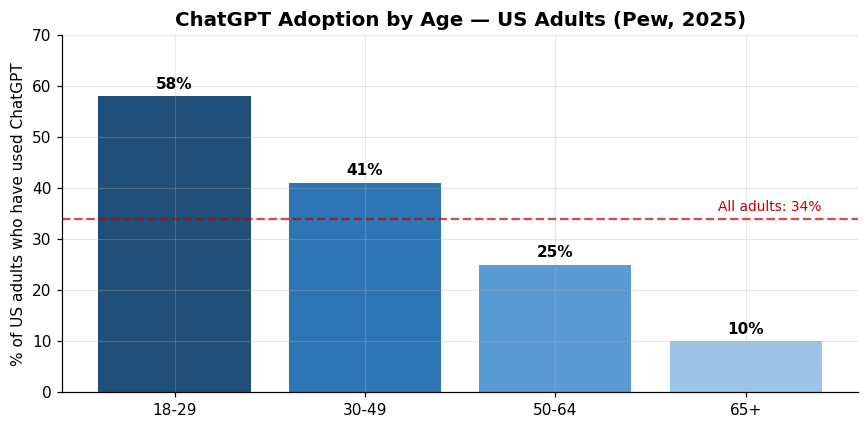

In [6]:
ages = ['18-29', '30-49', '50-64', '65+']
pcts = [58, 41, 25, 10]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ages, pcts, color=['#1F4E78', '#2E75B6', '#5B9BD5', '#9DC3E6'])
for i, p in enumerate(pcts):
    ax.text(i, p + 1.5, f'{p}%', ha='center', fontweight='bold')
ax.axhline(34, color='#C00000', linestyle='--', alpha=0.7)
ax.text(3.4, 35.5, 'All adults: 34%', color='#C00000', ha='right', fontsize=9)
ax.set_ylabel('% of US adults who have used ChatGPT')
ax.set_title('ChatGPT Adoption by Age — US Adults (Pew, 2025)')
ax.set_ylim(0, 70)
plt.tight_layout(); plt.show()

Adults under 30 are **5.8x more likely** to have used ChatGPT than those 65+ (58% vs 10%). Pew's December 2025 teen data shows a similar income gradient: 66% of teens in $75k+ households use ChatGPT vs. 56% in households under $30k.

### 4.2 Across countries: Adoption vs. GDP per capita

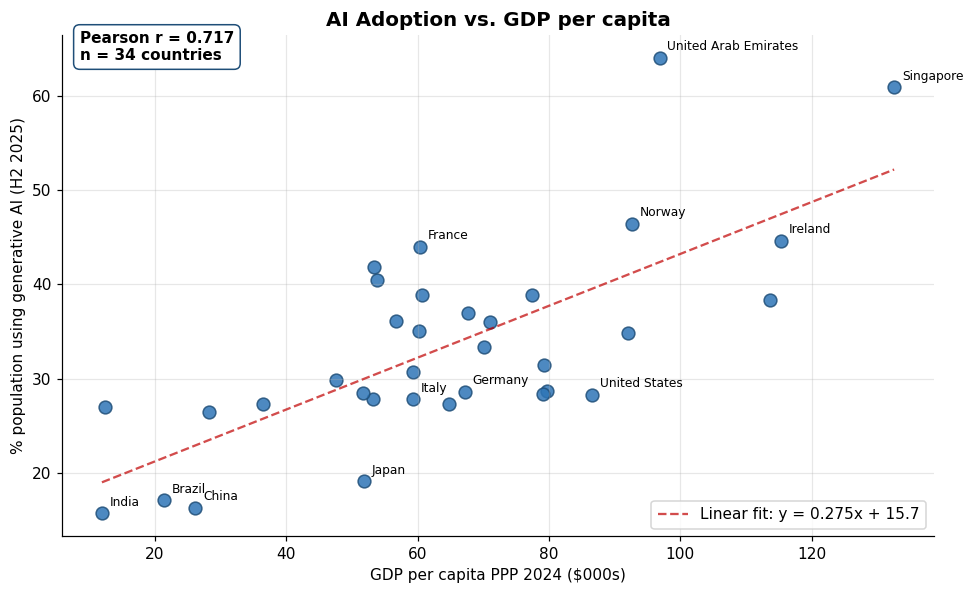

In [7]:
sub = master.dropna(subset=['Adoption', 'GDP_PPP']).copy()
sub['Adoption'] = sub['Adoption'].astype(float)
sub['GDP_PPP'] = sub['GDP_PPP'].astype(float)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(sub['GDP_PPP']/1000, sub['Adoption']*100, s=70, color='#2E75B6',
           edgecolor='#1F4E78', alpha=0.85)
for _, row in sub.iterrows():
    if row['Country'] in ['United Arab Emirates', 'Singapore', 'Norway', 'Ireland',
                          'France', 'United States', 'China', 'India', 'Japan',
                          'Germany', 'Brazil', 'Italy']:
        ax.annotate(row['Country'], (row['GDP_PPP']/1000, row['Adoption']*100),
                    xytext=(5,5), textcoords='offset points', fontsize=8)
z = np.polyfit(sub['GDP_PPP']/1000, sub['Adoption']*100, 1)
xx = np.linspace(sub['GDP_PPP'].min()/1000, sub['GDP_PPP'].max()/1000, 100)
ax.plot(xx, z[0]*xx + z[1], '--', color='#C00000', alpha=0.7,
        label=f'Linear fit: y = {z[0]:.3f}x + {z[1]:.1f}')
r, n = corr_with('Adoption', 'GDP_PPP')
ax.text(0.02, 0.95, f'Pearson r = {r}\nn = {n} countries', transform=ax.transAxes,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#1F4E78'))
ax.set_xlabel('GDP per capita PPP 2024 ($000s)')
ax.set_ylabel('% population using generative AI (H2 2025)')
ax.set_title('AI Adoption vs. GDP per capita')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

### 4.3 The optimism paradox

The most surprising finding in this dataset: AI optimism and AI adoption are **inversely** related at the country level. The countries that use AI most are the most skeptical of it; the countries that are most enthusiastic about AI use it least.

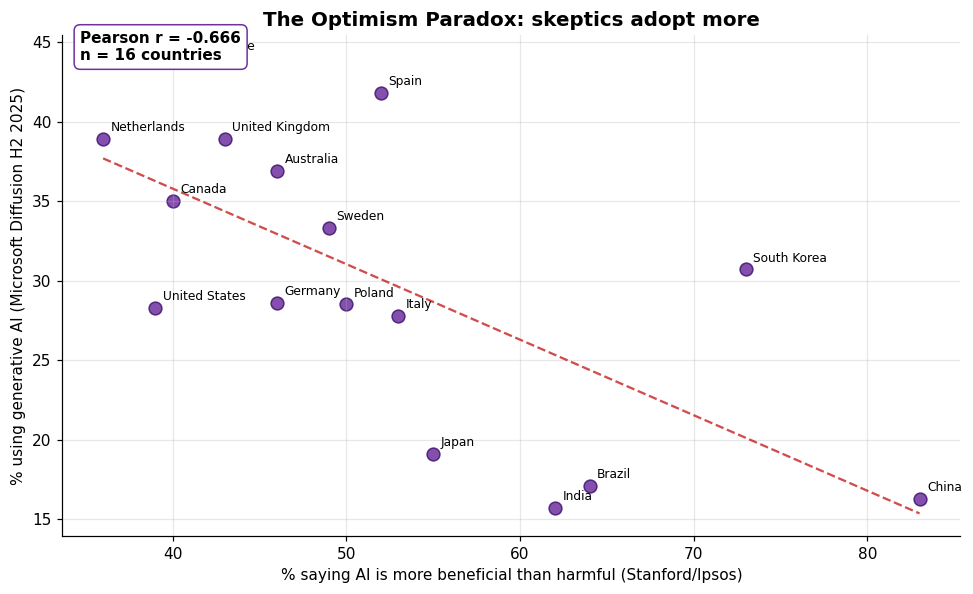

In [8]:
sub = master.dropna(subset=['Adoption', 'Optimism']).copy()
sub['Adoption'] = sub['Adoption'].astype(float); sub['Optimism'] = sub['Optimism'].astype(float)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(sub['Optimism']*100, sub['Adoption']*100, s=70, color='#7030A0',
           edgecolor='#3F1670', alpha=0.85)
for _, row in sub.iterrows():
    ax.annotate(row['Country'], (row['Optimism']*100, row['Adoption']*100),
                xytext=(5,5), textcoords='offset points', fontsize=8)
z = np.polyfit(sub['Optimism'], sub['Adoption'], 1)
xx = np.linspace(sub['Optimism'].min(), sub['Optimism'].max(), 100)
ax.plot(xx*100, (z[0]*xx + z[1])*100, '--', color='#C00000', alpha=0.7)
r, n = corr_with('Adoption', 'Optimism')
ax.text(0.02, 0.95, f'Pearson r = {r}\nn = {n} countries', transform=ax.transAxes,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#7030A0'))
ax.set_xlabel('% saying AI is more beneficial than harmful (Stanford/Ipsos)')
ax.set_ylabel('% using generative AI (Microsoft Diffusion H2 2025)')
ax.set_title('The Optimism Paradox: skeptics adopt more')
plt.tight_layout(); plt.show()

## 5. Limitations and scope of inference

1. **Source comparability.** Different surveys define 'adoption' differently (have-ever-used vs. used-in-last-3-months vs. daily). Cross-source comparisons are indicative, not exact.
2. **Online sampling bias.** Most country-level surveys are administered online, biasing samples toward already-connected populations and likely overstating adoption in lower-internet countries.
3. **Correlational only.** All findings here are cross-sectional Pearson correlations. Causation cannot be established — reverse causation (AI adoption raising productivity, hence GDP) is plausible at the margin.
4. **N is small for optimism analysis (n=16).** A larger sample is needed to firmly establish the optimism paradox; the current effect size is large enough to be unlikely as noise but a robustness check on a larger sample is warranted.
5. **US income breakdown for adults is incomplete.** Pew's adult ChatGPT-by-income tabulation isn't in the headline 2025 release; income evidence for adults relies on Brookings narrative summary rather than precise tabulations.

**Scope of inference.** Findings apply to the 34 countries in the merged sample, weighted toward OECD and middle-income economies. Generalization to low-income countries (especially Sub-Saharan Africa) is not supported by this data.

## 6. Refined hypothesis

**Original hypothesis (supported):** Generative AI adoption follows existing digital-divide patterns within and across countries.

**Added refinement (new):** Public sentiment about AI is *decoupled from*, and in fact inversely related to, actual usage. "Do people like AI?" and "Do people use AI?" measure different things at the country level. Future work should treat adoption and optimism as distinct outcomes.

**Next analytical steps:** (a) multivariate regression controlling GDP, internet, and education simultaneously; (b) within-country time-series to test whether the digital divide is widening or narrowing; (c) deeper US income breakdown from US Census HTOPS public-use file; (d) sectoral analysis from Anthropic's Economic Index to test whether high-skill occupations dominate adoption.